### Problem Statement



The objective of this project is to build a machine learning regression model that predicts house prices in India based on property characteristics such as number of bedrooms, bathrooms, location and related features.

This model can help buyers, sellers, and real estate companies make data-driven pricing decisions.

### Import modules

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns  
import warnings 
warnings.filterwarnings("ignore")

### Load dataset

In [2]:
path=r"C:\Users\devav\Downloads\ML-House\House Price India.csv"

In [3]:
data=pd.read_csv(path)
data.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


### Learns about dataset

In [4]:
data.shape

(14619, 23)

In [5]:
data.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')

In [6]:
data.dtypes

id                                         int64
Date                                       int64
number of bedrooms                         int64
number of bathrooms                      float64
living area                                int64
lot area                                   int64
number of floors                         float64
waterfront present                         int64
number of views                            int64
condition of the house                     int64
grade of the house                         int64
Area of the house(excluding basement)      int64
Area of the basement                       int64
Built Year                                 int64
Renovation Year                            int64
Postal Code                                int64
Lattitude                                float64
Longitude                                float64
living_area_renov                          int64
lot_area_renov                             int64
Number of schools ne

In [7]:
data.info

<bound method DataFrame.info of                id   Date  number of bedrooms  number of bathrooms  \
0      6762810635  42491                   4                 2.50   
1      6762810998  42491                   5                 2.75   
2      6762812605  42491                   4                 2.50   
3      6762812919  42491                   3                 2.00   
4      6762813105  42491                   3                 2.50   
...           ...    ...                 ...                  ...   
14614  6762830250  42734                   2                 1.50   
14615  6762830339  42734                   3                 2.00   
14616  6762830618  42734                   2                 1.00   
14617  6762830709  42734                   4                 1.00   
14618  6762831463  42734                   3                 1.00   

       living area  lot area  number of floors  waterfront present  \
0             2920      4000               1.5                   0   

### correlation b/w target and features
**To select the fetures**

<Axes: >

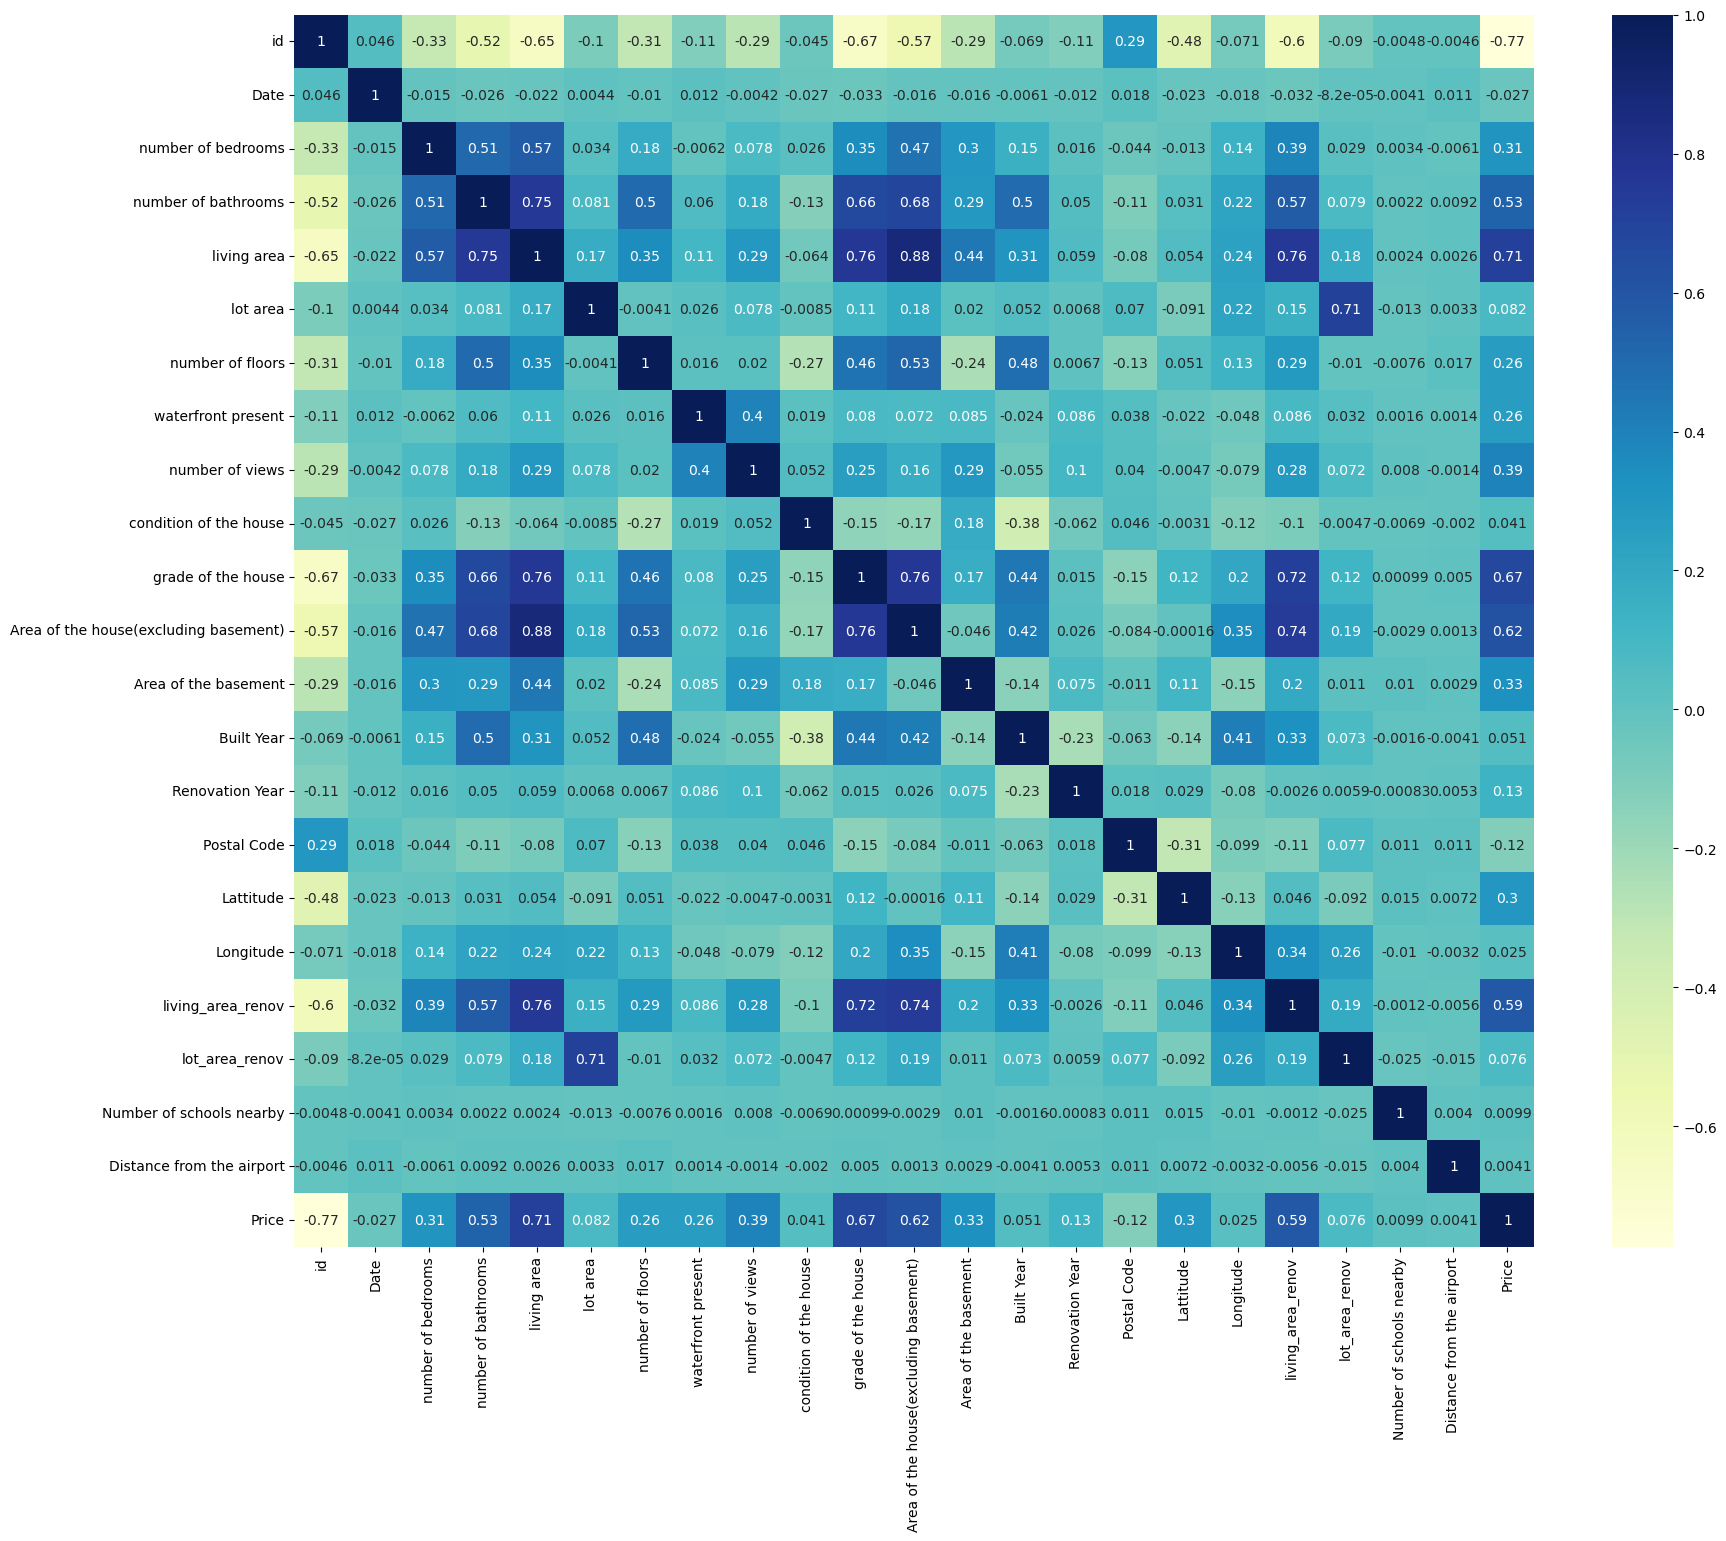

In [8]:
plt.figure(figsize=(20,16))
sns.heatmap(data.corr(), annot=True, cmap='YlGnBu')

In [9]:
df=data[['number of bedrooms','number of bathrooms','living area','number of floors', 'waterfront present','number of views',
'grade of the house','Area of the house(excluding basement)', 'Area of the basement','Built Year',
'Renovation Year','living_area_renov',"Price"]]


df=data[['number of bedrooms', 'number of bathrooms',
'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov', 'Price']]
df.shape


(14619, 18)

In [10]:
df.corr()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Built Year,Renovation Year,Lattitude,Longitude,living_area_renov,lot_area_renov,Price
number of bedrooms,1.000000,0.509783,0.570441,0.034438,0.177208,-0.006247,0.078157,0.026326,0.352795,0.473482,0.300367,0.153184,0.016159,-0.013226,0.135859,0.389765,0.029436,0.308165
number of bathrooms,0.509783,1.000000,0.753540,0.080812,0.502912,0.060107,0.183780,-0.128335,0.663082,0.684418,0.287194,0.498235,0.049676,0.031139,0.223950,0.570524,0.078637,0.532031
living area,0.570441,0.753540,1.000000,0.174455,0.354682,0.105858,0.287431,-0.063646,0.761783,0.875767,0.441537,0.309856,0.059431,0.054464,0.240365,0.757540,0.180362,0.712276
lot area,0.034438,0.080812,0.174455,1.000000,-0.004128,0.026281,0.078427,-0.008524,0.110582,0.183596,0.019755,0.051602,0.006846,-0.090978,0.221429,0.149766,0.706811,0.082117
number of floors,0.177208,0.502912,0.354682,-0.004128,1.000000,0.016322,0.019860,-0.270136,0.463033,0.525604,-0.242980,0.481733,0.006719,0.050700,0.127627,0.285037,-0.010103,0.262649
waterfront present,-0.006247,0.060107,0.105858,0.026281,0.016322,1.000000,0.400567,0.018662,0.079853,0.071885,0.085441,-0.024238,0.085863,-0.021792,-0.047799,0.085755,0.032053,0.263943
number of views,0.078157,0.183780,0.287431,0.078427,0.019860,0.400567,1.000000,0.051791,0.254112,0.162193,0.293317,-0.054839,0.103103,-0.004734,-0.079411,0.281270,0.072455,0.394954
condition of the house,0.026326,-0.128335,-0.063646,-0.008524,-0.270136,0.018662,0.051791,1.000000,-0.152898,-0.168052,0.180650,-0.381554,-0.062103,-0.003083,-0.121042,-0.099974,-0.004704,0.040609
grade of the house,0.352795,0.663082,0.761783,0.110582,0.463033,0.079853,0.254112,-0.152898,1.000000,0.758161,0.167187,0.440689,0.014532,0.115202,0.203935,0.719983,0.116779,0.671805
Area of the house(excluding basement),0.473482,0.684418,0.875767,0.183596,0.525604,0.071885,0.162193,-0.168052,0.758161,1.000000,-0.046446,0.419679,0.025758,-0.000155,0.346094,0.737710,0.194730,0.615179


In [11]:
"""df['Age'] = 2026 - df['Built Year']
df"""

"df['Age'] = 2026 - df['Built Year']\ndf"

In [12]:
#df.to_csv(r"C:\Users\devav\Downloads\ML-House\House_predict_data.csv",index=False)

In [13]:
#df=pd.read_csv(r"C:\Users\devav\Downloads\ML-House\House_predict_data.csv")

In [14]:
df.head()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Built Year,Renovation Year,Lattitude,Longitude,living_area_renov,lot_area_renov,Price
0,4,2.50,2920,4000,1.5,0,0,5,8,1910,1010,1909,0,52.8878,-114.470,2470,4000,1400000
1,5,2.75,2910,9480,1.5,0,0,3,8,2910,0,1939,0,52.8852,-114.468,2940,6600,1200000
2,4,2.50,3310,42998,2.0,0,0,3,9,3310,0,2001,0,52.9532,-114.321,3350,42847,838000
3,3,2.00,2710,4500,1.5,0,0,4,8,1880,830,1929,0,52.9047,-114.485,2060,4500,805000
4,3,2.50,2600,4750,1.0,0,0,4,9,1700,900,1951,0,52.9133,-114.590,2380,4750,790000


In [15]:
df.shape

(14619, 18)

In [16]:
df.dtypes

number of bedrooms                         int64
number of bathrooms                      float64
living area                                int64
lot area                                   int64
number of floors                         float64
waterfront present                         int64
number of views                            int64
condition of the house                     int64
grade of the house                         int64
Area of the house(excluding basement)      int64
Area of the basement                       int64
Built Year                                 int64
Renovation Year                            int64
Lattitude                                float64
Longitude                                float64
living_area_renov                          int64
lot_area_renov                             int64
Price                                      int64
dtype: object

## Clean the data

### Checking null vaues

In [17]:
df.isnull().sum()

number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Price                                    0
dtype: int64

### Checking duplicate values

In [18]:
df.duplicated().sum()

np.int64(2)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()

np.int64(0)

### Outliers dection

In [21]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols == df.columns


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [22]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5* IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = outliers.shape[0]

outlier_summary


{'number of bedrooms': 361,
 'number of bathrooms': 379,
 'living area': 395,
 'lot area': 1652,
 'number of floors': 0,
 'waterfront present': 112,
 'number of views': 1420,
 'condition of the house': 18,
 'grade of the house': 1319,
 'Area of the house(excluding basement)': 402,
 'Area of the basement': 287,
 'Built Year': 0,
 'Renovation Year': 665,
 'Lattitude': 3,
 'Longitude': 184,
 'living_area_renov': 338,
 'lot_area_renov': 1517,
 'Price': 760}

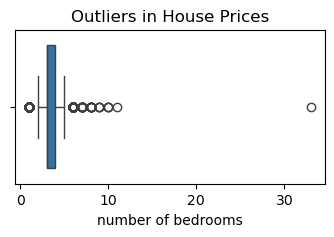

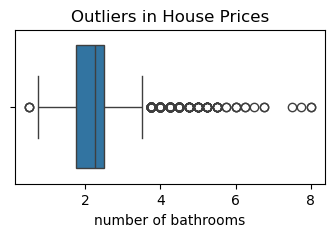

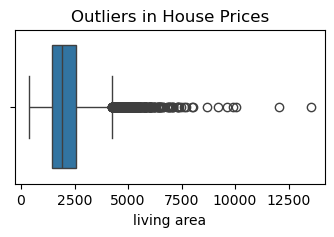

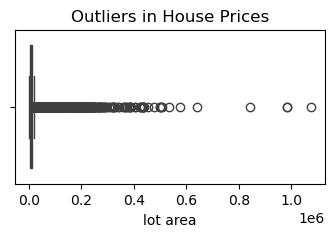

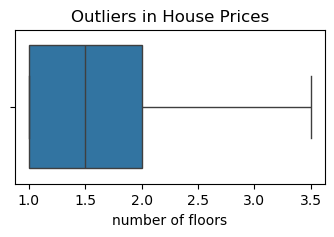

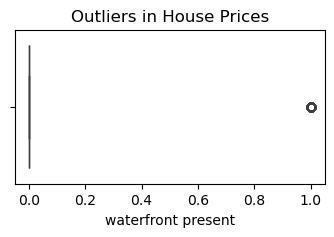

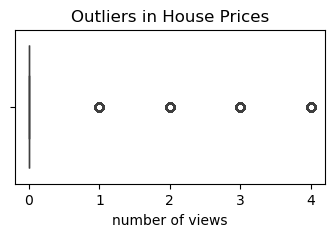

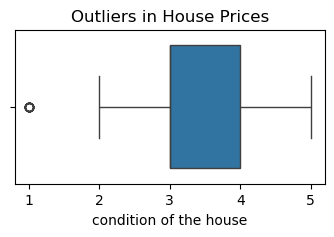

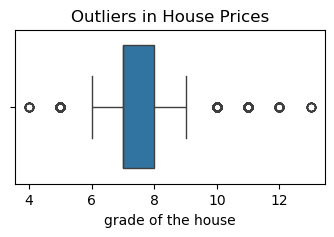

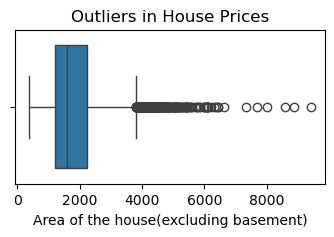

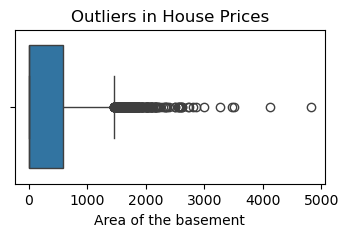

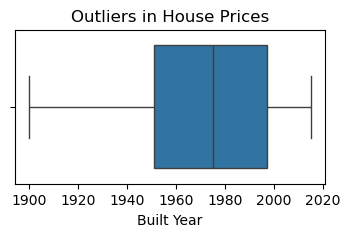

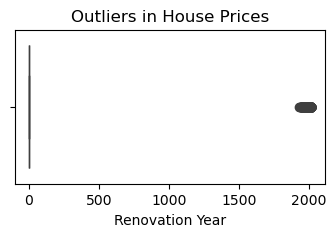

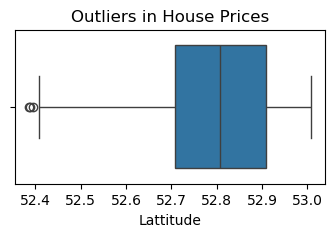

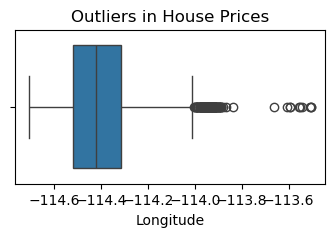

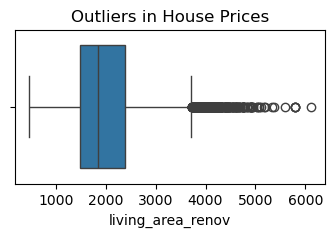

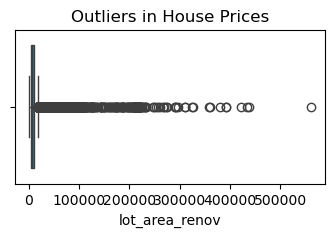

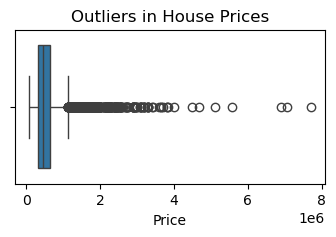

In [23]:
for i in df.columns: 
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[i])
    plt.title("Outliers in House Prices")
    plt.show()

In [24]:
df.columns

Index(['number of bedrooms', 'number of bathrooms', 'living area', 'lot area',
       'number of floors', 'waterfront present', 'number of views',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Lattitude', 'Longitude',
       'living_area_renov', 'lot_area_renov', 'Price'],
      dtype='object')

In [25]:
df['number of bedrooms'].value_counts()

number of bedrooms
3     6611
4     4723
2     1844
5     1078
6      176
1      136
7       30
8       11
9        3
10       3
33       1
11       1
Name: count, dtype: int64


Values 1–11 → normal

33 bedrooms → not normal 

In [26]:
df = df[df["number of bedrooms"] != 33]
df.shape

(14616, 18)

In [27]:
df['number of bathrooms'].value_counts()

number of bathrooms
2.50    3676
1.00    2509
1.75    2060
2.25    1378
2.00    1323
1.50     968
2.75     831
3.00     510
3.50     504
3.25     424
3.75     101
4.00      81
4.50      72
4.25      56
0.75      47
4.75      17
5.00      15
5.25      12
5.50       8
1.25       7
0.50       3
6.00       3
8.00       2
5.75       2
6.25       2
6.75       2
6.50       1
7.50       1
7.75       1
Name: count, dtype: int64

1 to 7 is normal 

<7 is not normal

In [28]:
df = df[df["number of bathrooms"] <= 7]
df.shape

(14612, 18)

In [29]:
df['living area'].unique()
df["living area"].value_counts()

living area
1400    93
1010    92
1320    91
1660    90
1820    88
        ..
2448     1
2846     1
5320     1
5930     1
1556     1
Name: count, Length: 862, dtype: int64

These are not  outliers – just big houses

In [30]:
df['waterfront present'].value_counts()

waterfront present
0    14500
1      112
Name: count, dtype: int64

no outliers

In [31]:
df['number of views'].value_counts()

number of views
0    13195
2      636
3      349
1      219
4      213
Name: count, dtype: int64

 no outliers

In [32]:
df['grade of the house'].value_counts()

grade of the house
7     6009
8     4135
9     1828
6     1324
10     803
11     280
5      154
12      54
4       17
13       8
Name: count, dtype: int64

grade of house range is  0-10

In [33]:
df= df[df['grade of the house']<=10]

In [34]:
df['grade of the house'].value_counts()

grade of the house
7     6009
8     4135
9     1828
6     1324
10     803
5      154
4       17
Name: count, dtype: int64

In [35]:
df['Area of the house(excluding basement)'].unique()

array([1910, 2910, 3310, 1880, 1700, 3660, 1550, 1440, 1300, 2820, 1640,
       1520, 2710, 1470, 1560, 1360, 2730, 3240, 1970, 1140, 2190, 1130,
        880, 1460, 1710, 2680, 1570, 1270, 1080,  800, 1770, 1600, 1450,
       1070, 1000, 1930, 1650, 2300, 1040, 3110, 1090, 1350, 1580, 1160,
       1340,  850, 2540, 1280, 2200, 1800, 1180, 1480, 1370, 1200, 1210,
       2920,  900, 1010, 1990, 2010, 2220, 2850, 1690, 1330, 3410, 3200,
       3690, 1610, 3400, 2780, 3180, 1810, 1620, 2450, 2490, 1680, 1660,
       1050, 1400, 2440, 1960, 1670, 1320, 1900, 1940, 1110,  780, 1790,
       3040, 1540, 1590, 1410, 1408, 2110,  840, 2230, 1750, 1571, 1120,
       2370, 2310, 1240, 1430,  810, 1490, 4510, 3930, 2400, 2280, 2690,
       2080, 3740, 3880, 2290, 3030,  930, 3380, 1030, 2150, 3569, 1170,
       2000, 1850, 2460,  740, 2020, 1420, 2740, 3470, 1020, 1100,  960,
       1260, 1310, 1230,  860, 2331,  720,  980, 1630, 1060, 1890, 3900,
       3170, 1780, 3680, 2130, 1720, 2030, 1860, 37

These are NOT error or outliers – just big houses


In [36]:
df['Area of the basement'].unique()

array([1010,    0,  830,  900,  690,  950,  180,  280, 1170, 1000,  360,
        800,  670,  470,  750,  860, 1080,  170,  850,  310, 1330,  350,
        760,  730,  520, 1140,  630, 1160, 1500, 1290, 1300,  560,  140,
        540,  500,  340,  780,  720,  840,  250, 1220,  680, 1370,  160,
        740,  910, 1600,  300,   80,  440,  270, 1340,  920,  620, 1360,
       1210, 1400,  590,  940,  990, 1030,  870,  960,  700,  400, 1200,
        430,  790,  210, 1100,  880,  240, 1580,  490,  650,  420,  480,
        530,  640, 1130,  600, 1380, 1230,  570,  260,  370,  330, 1060,
        820,  220,  510, 1090,  890, 1460, 1070,  100,   70,  660, 1050,
       1760, 1250,  290,  550,  450,  710,  145,  200,  410,  150, 1120,
       1690, 1350, 1280,  980, 1420,   90, 1260,  930, 1190,  610, 1180,
        320,  810, 1270,  390, 1540,  580, 1020,  516, 1700, 1480,  770,
        120,  894,  380, 1740, 1110, 1950,  130, 1510,  970, 1040, 1910,
       1670,  230,   60, 1660,  906,  110, 1620, 20

These are NOT error or outliers – just big houses

In [37]:
df['Renovation Year'].unique()

array([   0, 1994, 1954, 2011, 1998, 1992, 1958, 2014, 2002, 2004, 2013,
       1986, 2005, 1990, 2001, 1984, 1956, 2000, 2010, 2003, 1996, 1977,
       2007, 1983, 1970, 1981, 1975, 1971, 1988, 1999, 2009, 1995, 1969,
       1997, 2015, 1982, 1989, 2006, 1985, 1993, 1953, 1955, 1979, 1987,
       1960, 1934, 1945, 2008, 2012, 1980, 1972, 1948, 1978, 1991, 1968,
       1974, 1965, 1946, 1940, 1963, 1976, 1964, 1973, 1967, 1944, 1959,
       1957, 1962])

all are year from 1994  to 2015

zeros means not  Renovation

In [38]:
df['living_area_renov'].unique()

array([2470, 2940, 3350, 2060, 2380, 3320, 1570, 2010, 2320, 2820, 1910,
       2390, 2410, 1300, 2730, 1860, 4050, 2570, 2200, 2590, 2860, 1090,
       3000, 1340, 2780, 2080, 2260, 2990, 1560, 1320, 1850, 1150, 1770,
       2340, 1680, 1260, 1450, 2070, 2290, 1960, 2830, 1440, 1790, 1160,
       1480, 1100, 2280, 1590, 1410, 2310, 1750, 2130, 1400, 1380, 1580,
       3030, 1280, 1940, 1390, 2315, 2240, 2350, 2140, 1870, 2610, 3100,
       4420, 4530, 3430, 2550, 1670, 3070, 2020, 3180, 2970, 1690, 2750,
       2170, 3715, 1950, 2580, 1810, 3010, 1350, 1720, 1800, 2840, 2330,
       1060, 2160, 2030, 1880, 1520, 2500, 1290, 1470, 1890, 1730, 2220,
       1840, 2670, 1200, 1408, 1620, 1430, 1630, 1310, 1760, 1820, 1220,
       1980, 1130, 1170, 1510, 1240, 2488, 3510, 2490, 2540, 2120, 2040,
       3040, 3240, 3130, 3770, 2790, 2800, 2530, 2450, 2520, 2770, 2000,
       1780, 2210, 1420, 1660, 1970, 1270, 1460, 1500, 1930, 1330, 1740,
       1370, 2090, 1230, 2441,  840, 2360, 1650, 14

These are NOT error or outliers – just big houses

In [39]:
df['lot area'].unique()

array([ 4000,  9480, 42998, ...,  3770, 10425,  6621], shape=(7229,))

all no outliers just big house 

In [40]:
 df['condition of the house'].unique()

array([5, 3, 4, 2, 1])

no outliers

In [41]:
 df['Lattitude'].unique()

array([52.8878, 52.8852, 52.9532, ..., 52.4919, 52.5075, 52.5338],
      shape=(4644,))

all are coordinates  so no  outliers 

In [42]:
df['Longitude'].unique()

array([-114.47 , -114.468, -114.321, -114.485, -114.59 , -114.05 ,
       -114.482, -114.598, -114.391, -114.215, -114.459, -114.177,
       -114.511, -114.515, -114.3  , -114.574, -114.395, -114.568,
       -114.236, -114.06 , -114.304, -114.225, -114.348, -114.496,
       -114.259, -114.512, -114.212, -114.412, -114.471, -113.924,
       -113.908, -114.582, -114.367, -114.554, -114.587, -114.181,
       -114.532, -114.325, -114.323, -114.324, -114.351, -114.53 ,
       -114.38 , -114.573, -114.371, -114.381, -114.555, -114.341,
       -114.297, -114.087, -114.262, -114.529, -114.518, -114.245,
       -114.553, -114.224, -114.493, -114.096, -113.977, -114.383,
       -114.503, -114.343, -114.55 , -114.334, -114.585, -114.207,
       -113.953, -114.479, -114.216, -114.406, -114.476, -114.35 ,
       -114.349, -114.263, -114.172, -114.299, -114.372, -114.228,
       -114.385, -114.219, -114.5  , -114.36 , -114.561, -114.307,
       -114.303, -114.183, -114.48 , -114.528, -114.559, -114.

all are coordinates  so no  outliers 

In [43]:
df['lot_area_renov'].unique()

array([ 4000,  6600, 42847, ...,  1608, 17286,  6631], shape=(6605,))

all no outliers just big house

In [44]:
df['Price'].unique()

array([1400000, 1200000,  838000, ...,  221700,  219200,  146000],
      shape=(2843,))

large area and building have high value

for all price  and  area realted colume we need to do log transfrom


In [45]:
'''log_cols = [
    "Price",
    "living area",
    "Area of the house(excluding basement)",
    "Area of the basement",
    "living_area_renov"
]

for col in log_cols:
    df[col] = np.log1p(df[col])'''

'log_cols = [\n    "Price",\n    "living area",\n    "Area of the house(excluding basement)",\n    "Area of the basement",\n    "living_area_renov"\n]\n\nfor col in log_cols:\n    df[col] = np.log1p(df[col])'

In [46]:
df.columns

Index(['number of bedrooms', 'number of bathrooms', 'living area', 'lot area',
       'number of floors', 'waterfront present', 'number of views',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Lattitude', 'Longitude',
       'living_area_renov', 'lot_area_renov', 'Price'],
      dtype='object')

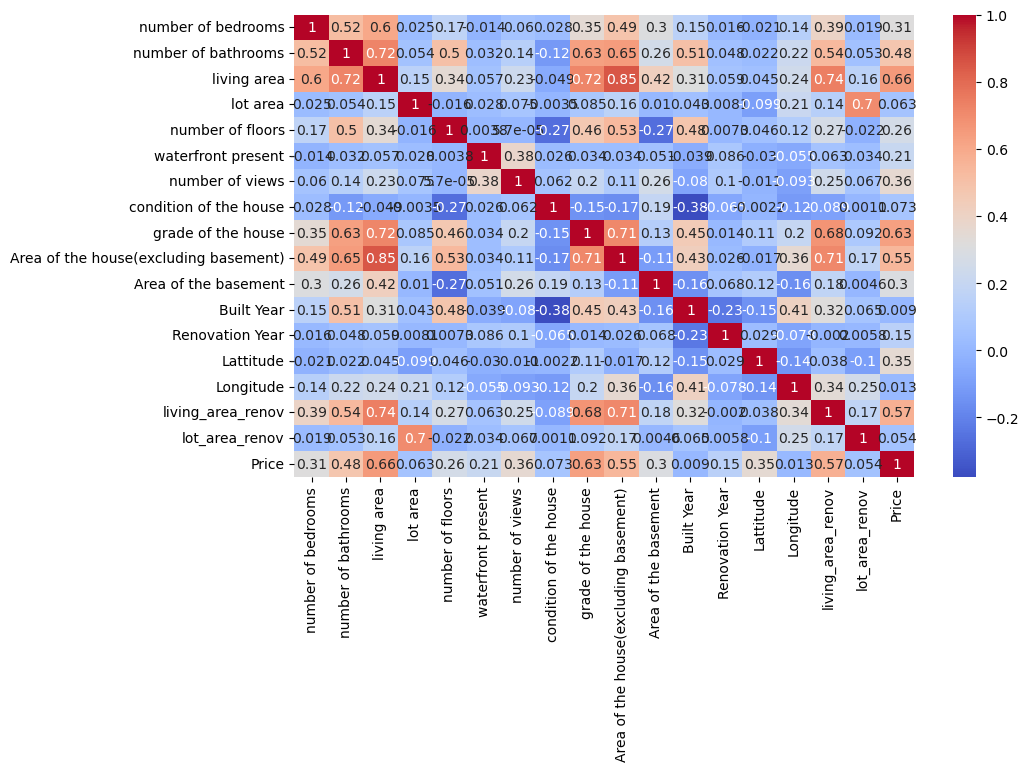

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


Houses with large living area + high grade have highest prices.

Location (latitude & longitude) significantly influences price.

Basement area also contributes to higher house prices.

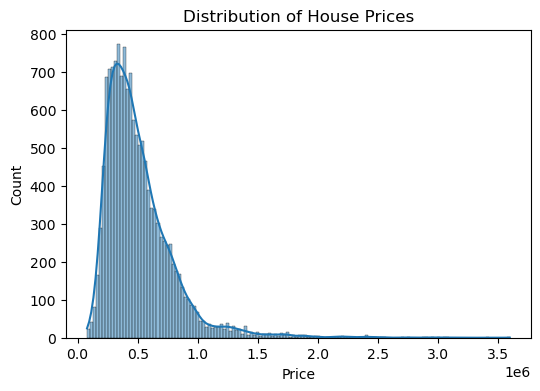

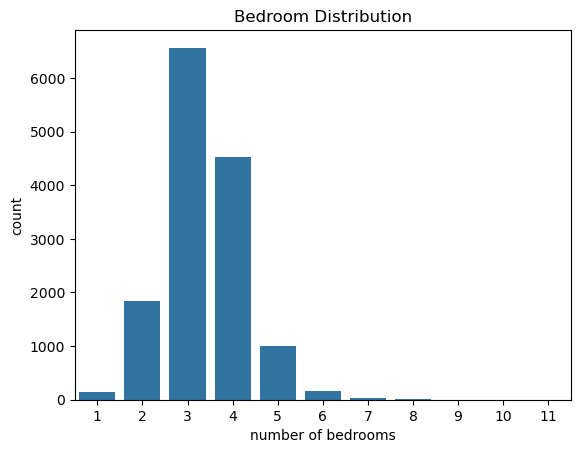

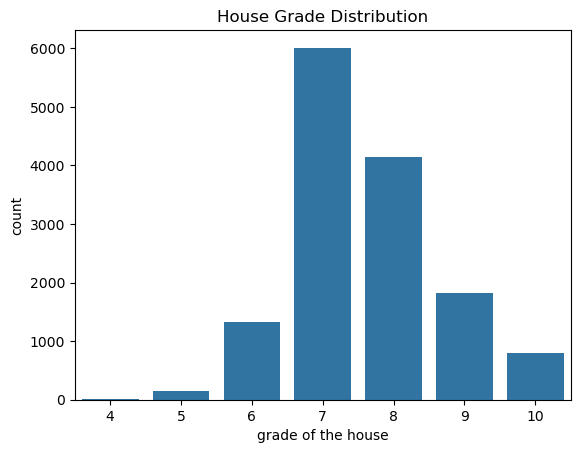

In [48]:

plt.figure(figsize=(6,4))
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of House Prices")
plt.show()

sns.countplot(x='number of bedrooms', data=df)
plt.title("Bedroom Distribution")
plt.show()

sns.countplot(x='grade of the house', data=df)
plt.title("House Grade Distribution")
plt.show()

Most houses have 3–4 bedrooms.

Price distribution is right-skewed.

Grade values mostly fall between 7–9.

Most houses do not have waterfront views.

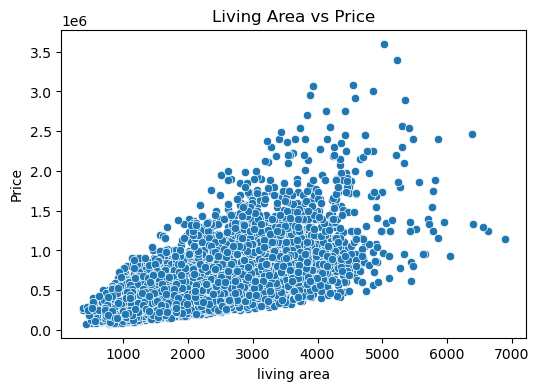

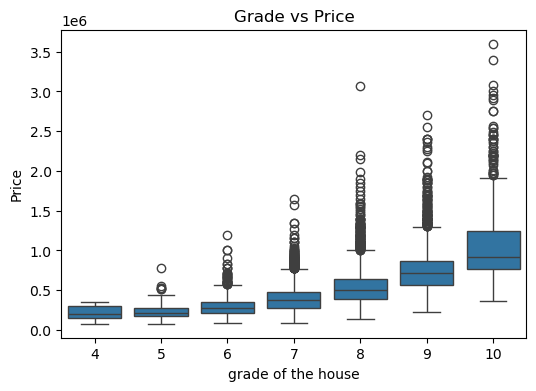

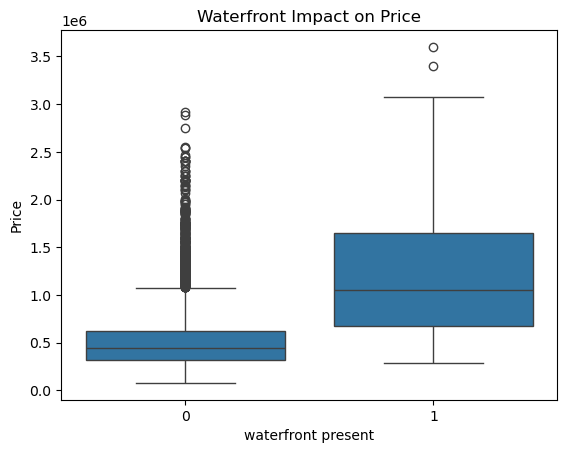

In [49]:
# Living area vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x='living area', y='Price', data=df)
plt.title("Living Area vs Price")
plt.show()

# Grade vs Price
plt.figure(figsize=(6,4))
sns.boxplot(x='grade of the house', y='Price', data=df)
plt.title("Grade vs Price")
plt.show()

# Waterfront vs Price
sns.boxplot(x='waterfront present', y='Price', data=df)
plt.title("Waterfront Impact on Price")
plt.show()

Living area strongly correlates with price.

Houses with waterfront views have higher prices.

Higher grade houses tend to be more expensive.

### split the data

In [50]:
X = df.drop('Price', axis=1)
y = df['Price']


In [51]:
X.shape,y.shape

((14270, 17), (14270,))

### Train Test Split

In [52]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [53]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((11416, 17), (2854, 17), (11416,), (2854,))

### Scaling 

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train= scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)


### Model Selection from diff model

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


Linear Regression R2 Score: 0.6893347568233235
MSE: 25544234612.01179
MAE: 107430.1516807064
RMSE: 159825.63815612247


In [56]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


Random Forest R2 Score: 0.8579542632999669
MAE: 64141.93452527781
MSE: 11679612391.78013
RMSE: 108072.25542099198


In [57]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

print("Decision Tree R2 Score:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))



Decision Tree R2 Score: 0.6542075799238353
MAE: 93058.42747021724
MSE: 28432542421.41766
RMSE: 168619.51969276174


In [58]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

print("XGBoost R2 Score:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))


XGBoost R2 Score: 0.877133309841156
MAE: 61473.85546875
MSE: 10102626304.0
RMSE: 100511.82171267219


In [59]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(x_train, y_train)

pred_knn = knn.predict(x_test)

print("knn R2 Score:", r2_score(y_test, pred_knn))
print("MAE:", mean_absolute_error(y_test, pred_knn))
print("MSE:", mean_squared_error(y_test, pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_knn)))


knn R2 Score: 0.7576172709776191
MAE: 85772.36720392431
MSE: 19929752143.294186
RMSE: 141172.77408655745


In [60]:
print("Linear Regression:", r2_score(y_test, y_pred_lr))
print("Decision Tree:", r2_score(y_test, y_pred_dt))
print("Random Forest:", r2_score(y_test, y_pred_rf))
print("XGBoost:", r2_score(y_test, y_pred_xgb))
print("knn R2 Score:", r2_score(y_test, pred_knn))


Linear Regression: 0.6893347568233235
Decision Tree: 0.6542075799238353
Random Forest: 0.8579542632999669
XGBoost: 0.877133309841156
knn R2 Score: 0.7576172709776191


In [61]:
import pickle

with open("xgb_model.pkl", "wb") as file:
    pickle.dump(xgb, file)



In [62]:
print(xgb.score(x_train, y_train))
print(rf.score(x_train, y_train))

print(xgb.score(x_test, y_test))
print(rf.score(x_test, y_test))

0.9772716760635376
0.9813079241509621
0.877133309841156
0.8579542632999669


In [63]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[200,300,400],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1]
}

grid = GridSearchCV(XGBRegressor(), params, cv=5)
grid.fit(x_train, y_train)

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400}


In [64]:
grid_pred=grid.predict(x_test)
print("XGBoost:", r2_score(y_test, grid_pred))


XGBoost: 0.8847309947013855


In [65]:
best_model = grid.best_estimator_

In [66]:
print("Train R2:", best_model.score(x_train, y_train))
print("Test R2:", best_model.score(x_test, y_test))

Train R2: 0.9693909883499146
Test R2: 0.8847309947013855


In [67]:
print(grid.score(x_train, y_train))

print(grid.score(x_test, y_test))


0.9693909883499146
0.8847309947013855


In [68]:
import pickle

pickle.dump(best_model, open("xgb_tuned_model.pkl","wb"))